# LangGraph 에이전트
## 도구 없음

## 라이브러리 임포트

In [16]:
from swc_toolkit import SportsWorldCentralToolkit
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from typing import Literal

In [17]:
# 에이전트와 통신하는 데 사용할 메시지를 정의하는 라이브러리
from langchain_core.messages import HumanMessage
# Anthropic 모델을 사용하는 라이브러리
from langchain_anthropic import ChatAnthropic
# LangGraph 프레임워크의 여러 부분을 활성화하는 라이브러리
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
import logging
# 에이전트가 반환하는 메시지의 서식 지정을 위해 사용되는 라이브러리
from IPython.display import display, Image, Markdown
# 그래프를 시각화하는 데 사용되는 라이브러리
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

## 로깅 설정

In [18]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename="../logs/langgraph_notebook.ipynb.log",
    level=logging.INFO,
)

## 툴킷 생성
swc_toolkit = SportsWorldCentralToolkit()
tools = swc_toolkit.get_tools()

## 에이전트와 모델 설정

### `load_dotenv()` 를 사용하여 환경변수 설정

In [19]:
from dotenv import load_dotenv
load_dotenv('../.env')

True

### 사용가능한 모델 조회

In [20]:
import os
from anthropic import Anthropic
client = Anthropic(
    api_key=os.environ.get("ANTHROPIC_API_KEY"),  # This is the default and can be omitted
)
for model in client.models.list().data:
    print(model.id)

# 195 / 308

claude-opus-4-5-20251101
claude-haiku-4-5-20251001
claude-sonnet-4-5-20250929
claude-opus-4-1-20250805
claude-opus-4-20250514
claude-sonnet-4-20250514
claude-3-haiku-20240307


### 모델 설정

In [21]:
tool_node = ToolNode(tools)

model = ChatAnthropic(model="claude-haiku-4-5-20251001", 
                      temperature=0).bind_tools(tools)

def should_continue(state: MessagesState) -> Literal["tools", END]:
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

def call_model(state: MessagesState):
    messages = state['messages']
    response = model.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    should_continue,
)

workflow.add_edge("tools", 'agent')

checkpointer = MemorySaver()

app = workflow.compile(checkpointer=checkpointer)

## 그래프 시각화하기

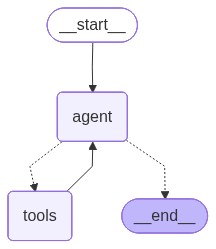

In [22]:
display(
    Image(app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API,))
)

## 에이전트와 대화하기

In [ ]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What are the leagues in the SportsWorldCentral fantasy football platform?")]},
    config={"configurable": {"thread_id": 99}},
)

display(Markdown(final_state["messages"][-1].content))

Here are the leagues available in the SportsWorldCentral fantasy football platform:

1. **Pigskin Prodigal Fantasy League** (League ID: 5001)
   - Scoring Type: PPR (Points Per Reception)
   - Teams: 12 teams
   - Last Updated: April 25, 2024

2. **Recurring Champions League** (League ID: 5002)
   - Scoring Type: Half-PPR
   - Teams: 8 teams
   - Last Updated: April 25, 2024

3. **AHAHFZZFFFL** (League ID: 5003)
   - Scoring Type: Half-PPR
   - Teams: 8 teams
   - Last Updated: April 25, 2024

4. **Gridiron Gurus Fantasy League** (League ID: 5004)
   - Scoring Type: PPR (Points Per Reception)
   - Teams: 12 teams
   - Last Updated: April 25, 2024

5. **Best League Ever** (League ID: 5005)
   - Scoring Type: PPR (Points Per Reception)
   - Teams: 12 teams
   - Last Updated: April 25, 2024

The platform has a total of 5 leagues with varying team counts and scoring formats. Would you like more details about any specific league or its teams?

In [ ]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What are the leagues in the SportsWorldCentral fantasy football platform? Keep the response simple plz.")]},
    config={"configurable": {"thread_id": 99}},
)

display(Markdown(final_state["messages"][-1].content))

Here are the leagues in SportsWorldCentral:

1. **Pigskin Prodigal Fantasy League** (PPR)
2. **Recurring Champions League** (Half-PPR)
3. **AHAHFZZFFFL** (Half-PPR)
4. **Gridiron Gurus Fantasy League** (PPR)
5. **Best League Ever** (PPR)

In [25]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="SportsWorldCentral 판타지 축구 플랫폼에서 리그는 무엇인가요?")]},
    config={"configurable": {"thread_id": 99}},
)

display(Markdown(final_state["messages"][-1].content))

SportsWorldCentral의 리그는 다음과 같습니다:

1. **Pigskin Prodigal Fantasy League** (PPR)
2. **Recurring Champions League** (Half-PPR)
3. **AHAHFZZFFFL** (Half-PPR)
4. **Gridiron Gurus Fantasy League** (PPR)
5. **Best League Ever** (PPR)